In [1]:
import warnings
warnings.filterwarnings("ignore")

# OS operations
import os
from pathlib import Path
# common datascience libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# deep-learning libraries
import torch
from torch import nn
from torch_geometric.data import Data
from torch_geometric.transforms import RandomNodeSplit

# from sklearn
from sklearn.model_selection import train_test_split

# code written by myself
import NN_models
import train_loop

In [2]:
cur_path = Path().resolve()
dataset_dir = Path().resolve().parent/"datasets/Graph_Datasets/elliptic_bitcoin_dataset"
csv_f =  os.listdir(dataset_dir)
print(csv_f)

['elliptic_txs_classes.csv', 'elliptic_txs_edgelist.csv', 'elliptic_txs_features.csv']


Three datasets:
1) 'elliptic_txs_classes.csv': classes of each node
2) 'elliptic_txs_edgelist.csv': edges of the graph dataset
3) 'elliptic_txs_features.csv': node features dataset

# Dataset

## Node Level Data

In [3]:
graph_node_f_df = pd.read_csv(dataset_dir/f"{csv_f[2]}", header=None)
graph_node_f_df = graph_node_f_df.rename(columns={0:"Node"})
i = 1
for col in graph_node_f_df.columns[1:]:
    graph_node_f_df.rename(columns={col:f"Feature_{col}"})
graph_node_f_df.head(5)

,Node,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [4]:
nodes = {} # map node_ids to integers for using with torch_geometric 
ind = 0
for i in graph_node_f_df["Node"]:
    if i not in nodes.keys():
        nodes[i] = ind
        ind += 1
    else:
        continue
len(nodes)

203769

In [5]:
graph_node_f_df["Node"] = graph_node_f_df["Node"].apply(lambda x: nodes[x]) # rename nodes

In [6]:
graph_node_f_df.dtypes

Node      int64
1         int64
2       float64
3       float64
4       float64
         ...   
162     float64
163     float64
164     float64
165     float64
166     float64
Length: 167, dtype: object

Most columns appear to be a float64 dtype. However, Feature 1 is int dtype. From the cell above, it can be observed that columns: Node and 1 are the only columns with dtype int64.  

In [7]:
graph_node_f_df.dtypes.drop_duplicates()

Node      int64
2       float64
dtype: object

Based on the values in column 1. We can see that this is most likely a categorical feature and will be on hot-encoded during preprocessing. 

In [8]:
graph_node_f_df[1].drop_duplicates()

0          1
7880       2
12424      3
19045      4
24738      5
31541      6
35869      7
41917      8
46374      9
51370     10
58097     11
62393     12
64440     13
68968     14
70990     15
74629     16
77604     17
80989     18
82965     19
86471     20
90762     21
94299     22
100193    23
104358    24
108950    25
111264    26
113787    27
114876    28
116529    29
120804    30
123287    31
126103    32
130628    33
133779    34
136265    35
141772    36
148165    37
151471    38
154362    39
157122    40
161603    41
166945    42
174085    43
179148    44
184123    45
189721    46
193240    47
198361    48
201315    49
Name: 1, dtype: int64

## Edge Data

In [9]:
graph_edges_df = pd.read_csv(dataset_dir/f"{csv_f[1]}")
graph_edges_df.head(5)

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


No null values present.

In [10]:
graph_edges_df.isna().sum()

txId1    0
txId2    0
dtype: int64

In [11]:
graph_edges_df["txId1"] = graph_edges_df["txId1"].apply(lambda x: nodes[x])
graph_edges_df["txId2"] = graph_edges_df["txId2"].apply(lambda x: nodes[x])

In [12]:
graph_edges_df.head(5)

,txId1,txId2
0,0,1
1,2,3
2,4,5
3,6,7
4,8,9


## Node Classes- Outputs

In [13]:
graph_node_class = pd.read_csv(dataset_dir/f"{csv_f[0]}")
print(graph_node_class.columns)
graph_node_class['txId'] = graph_node_class['txId'].apply(lambda x: nodes[x])
graph_node_class['Node'] = graph_node_class['txId']
graph_node_class = graph_node_class.drop(columns=["txId"])
graph_node_class["class"] = graph_node_class["class"].apply(lambda x: 0 if x=="unknown" else int(x))
graph_node_class.head(7)

Index(['txId', 'class'], dtype='object')


,class,Node
0,0,0
1,0,1
2,0,2
3,2,3
4,0,4
5,0,5
6,0,6


In [14]:
len(graph_node_class)==len(graph_node_f_df)

True

In [15]:
graph_node_class["class"].value_counts()

class
0    157205
2     42019
1      4545
Name: count, dtype: int64

In [16]:
(graph_node_class["Node"]==graph_node_f_df["Node"]).drop_duplicates()

0    True
Name: Node, dtype: bool

<Axes: xlabel='class', ylabel='Count'>

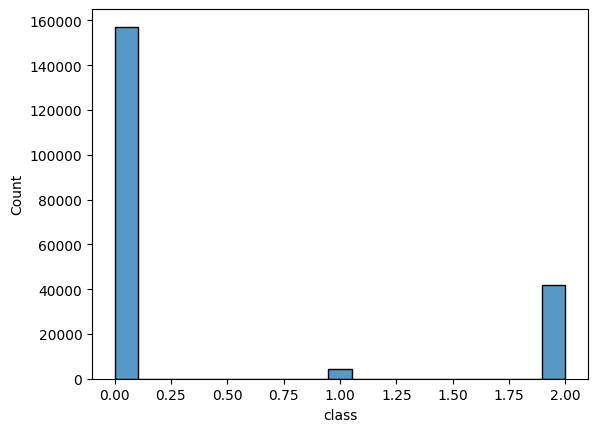

In [17]:
sns.histplot(data=graph_node_class, x="class")

In [18]:
nodes, class__ = graph_node_class["Node"], graph_node_class["class"]

In [19]:
train_nodes, test_nodes, y_train, y_test = train_test_split(nodes, class__, test_size=0.1, stratify=class__)
val_nodes, test_nodes, y_val, y_test = train_test_split(test_nodes, y_test, test_size=0.5, stratify=y_test)

In [20]:
train_nodes, val_nodes, test_nodes = set(train_nodes), set(val_nodes), set(test_nodes)
train_mask = graph_node_class["Node"].apply(lambda x: True if x in train_nodes else False)
val_mask = graph_node_class["Node"].apply(lambda x: True if x in val_nodes else False)
test_mask = graph_node_class["Node"].apply(lambda x: True if x in test_nodes else False)

There appears to be an imabalance in classes. Therefore a potential method to adress class imbalances could be to augment the training set by over sampling the minority classes in the training set.

# Deep Learning- Graph NN

## Data Preparation

In [21]:
edge_index= torch.from_numpy(graph_edges_df.to_numpy()).type(torch.long)
edge_index

tensor([[     0,      1],
        [     2,      3],
        [     4,      5],
        ...,
        [201921, 202042],
        [201480, 201368],
        [201954, 201756]])

In [22]:
# convert node names to a long tensor
nodes = torch.from_numpy(graph_node_f_df.to_numpy()[:,0]).type(torch.long)
# convert nodes features to a tensor
node_features = torch.from_numpy(graph_node_f_df.to_numpy()[:,1:]).type(torch.float)
# one hot enocoding for first column
node_feature_cat = node_features[:,0].type(torch.long)
node_feature_cat = nn.functional.one_hot(node_feature_cat).type(torch.float)
# concatenating tensors
node_features = torch.cat((node_feature_cat, node_features[:,1:]), dim=1).type(torch.float)

In [23]:
node_features.type()

'torch.FloatTensor'

In [24]:
node_classes = torch.from_numpy(graph_node_class.to_numpy()[:,0]).type(torch.long)

In [25]:
node_features, nodes, node_classes

(tensor([[ 0.0000,  1.0000,  0.0000,  ..., -0.0975, -0.1206, -0.1198],
         [ 0.0000,  1.0000,  0.0000,  ..., -0.0975, -0.1206, -0.1198],
         [ 0.0000,  1.0000,  0.0000,  ..., -0.1837, -0.1206, -0.1198],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ..., -0.0975, -0.1206, -0.1198],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.1406,  1.5197,  1.5214],
         [ 0.0000,  0.0000,  0.0000,  ..., -0.1406,  1.5197,  1.5214]]),
 tensor([     0,      1,      2,  ..., 203766, 203767, 203768]),
 tensor([0, 0, 0,  ..., 1, 0, 0]))

In [26]:
graph_data = Data(X=node_features, edge_index=edge_index.t().contiguous(), y=node_classes)
graph_data

Data(edge_index=[2, 234355], y=[203769], X=[203769, 215])

In [27]:
convert_df_to_mask = lambda mask: torch.from_numpy(mask.to_numpy())
train_mask, test_mask, val_mask = convert_df_to_mask(train_mask), convert_df_to_mask(test_mask), convert_df_to_mask(val_mask)  

In [28]:
graph_data.train_mask = train_mask
graph_data.val_mask = val_mask
graph_data.test_mask = test_mask

In [29]:
graph_data

Data(edge_index=[2, 234355], y=[203769], X=[203769, 215], train_mask=[203769], val_mask=[203769], test_mask=[203769])

# GNN Training

In [30]:
model = NN_models.GNN_Model(graph_data["X"].shape[1], 1024, 3, 5, 0.1)

In [31]:
training_loop = train_loop.ModelTraining(model, graph_data)

In [32]:
training_loop.training_loop(cur_path/"GNN_best.pth")

100%|██████████| 100/100 [09:19<00:00,  5.59s/epoch, training_accuracy=84.6, training_loss=0.437, validation_accuracy=79.4, validation_loss=0.573]
